# First pipeline 2026/01/12
### (no GH constraints, 3D density for orbital weights, and kinematics for hyperparameters)

In [4]:

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants import *
from utils import *

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc

path = '/home/hz420/python_script/SchwarMAX/'

In [2]:
@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned = model(params_halo_pot, params_disk_rho, dict_data)
    vr_binned = jnp.where(jnp.isnan(vr_binned), 0.0, vr_binned)
    sigmavr_binned = jnp.where(jnp.isnan(sigmavr_binned), 0.0, sigmavr_binned)
    vphi_binned = jnp.where(jnp.isnan(vphi_binned), 0.0, vphi_binned)
    sigmavphi_binned = jnp.where(jnp.isnan(sigmavphi_binned), 0.0, sigmavphi_binned)
    vz_binned = jnp.where(jnp.isnan(vz_binned), 0.0, vz_binned)
    sigmavz_binned = jnp.where(jnp.isnan(sigmavz_binned), 0.0, sigmavz_binned)

    frac_err = 0.1

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vr_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vphi_data_binned'] - vphi_binned)**2) / (frac_err * dict_data['vphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vz_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavr_data_binned'] - sigmavr_binned)**2) / (frac_err * dict_data['sigmavr_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavphi_data_binned'] - sigmavphi_binned)**2) / (frac_err * dict_data['sigmavphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavz_data_binned'] - sigmavz_binned)**2) / (frac_err * dict_data['sigmavz_data_binned'] + 1e-3) )

    return log_likelihood

@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = 0.01 * y + 1 # jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

    r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
    vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
    vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

    vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
    vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

    vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

    return vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

In [6]:


with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-64194924.0


In [ ]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

# Second pipeline 2026/01/19
### (add ic sampling, 3D density + 2D density + 2D h1-h4 for orbital weights, and V, sigma, h3, h4 for hyperparameters)

In [1]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

## Generating a mock data file for 3D density, 2D density and kinematics (assuming perfect edge-on)

In [49]:
EPSILON = 1e-12

# Load data
with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T

x, y = w0_data[:, 0], w0_data[:, 1]
R, phi = jnp.sqrt(w0_data[:, 0]**2 + w0_data[:, 1]**2), jnp.arctan2(w0_data[:, 1], w0_data[:, 0])
z, vy = w0_data[:, 2], w0_data[:, 4]

x = np.random.normal(x, 0., size=x.shape)
y = np.random.normal(y, 0., size=y.shape)
z = np.random.normal(z, 0., size=z.shape)

Rzphi_stars = jnp.stack([R, z, phi], axis=-1)
XY_stars = jnp.stack([x, z], axis=-1) # prefect edge-on view
print('Rzphi_stars shape:', Rzphi_stars.shape, 'XY_stars shape:', XY_stars.shape)


R_min, R_max =0., 10.
z_min, z_max = -1.5, 1.5
n_R, n_z, n_phi =10, 6, 6

R_edge = jnp.linspace(R_min, R_max, n_R+1)
z_edge = jnp.linspace(z_min, z_max, n_z+1)
phi_edge = jnp.linspace(-jnp.pi, jnp.pi, n_phi+1)
R_mids, z_mids, phi_mids = 0.5 * (R_edge[:-1] + R_edge[1:]), 0.5 * (z_edge[:-1] + z_edge[1:]), 0.5 * (phi_edge[:-1] + phi_edge[1:])
dR, dz, dphi = R_edge[1]-R_edge[0], z_edge[1]-z_edge[0], phi_edge[1]-phi_edge[0]

R_mids_mesh, z_mids_mesh, phi_mids_mesh = jnp.meshgrid(R_mids, z_mids, phi_mids, indexing='ij')

Rzphi_mid_grid = jnp.stack([R_mids_mesh.ravel(), z_mids_mesh.ravel(), phi_mids_mesh.ravel()], axis=-1)  # (n_R*n_z*n_phi, 3)

# Get the central point of each bin
Rzphi_minmax=jnp.array([[R_min, R_max],[z_min, z_max],[-jnp.pi, jnp.pi]])
nRzphi=jnp.array([n_R,n_z,n_phi])
num_segments_Rzphi=nRzphi.prod()
Rzphi_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nRzphi[:-1])])
Rzphi_grid_indices = assign_regular_grid(Rzphi_mid_grid,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
# Grid id of Rzphi_grid_indices has the corresponding center Rzphi_mid_grid
_, COUNTS = jnp.unique(Rzphi_grid_indices, return_counts=True)
print('Total counts in Rzphi bins:', jnp.sum(COUNTS), 'and only 1 per bin:', jnp.all(COUNTS <= 1))

df_Rzphi = pd.DataFrame({
    'id': Rzphi_grid_indices,
    'R_grid': Rzphi_mid_grid[:,0],
    'z_grid': Rzphi_mid_grid[:,1],
    'phi_grid': Rzphi_mid_grid[:,2],
})

Rzphi_indices = assign_regular_grid(Rzphi_stars,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
Rzphi_bin_counts = jax.ops.segment_sum(jnp.ones_like(Rzphi_indices), Rzphi_indices, num_segments=num_segments_Rzphi)
index = jnp.arange(num_segments_Rzphi)
df_counts_Rzphi = pd.DataFrame({
    'id': index,
    'N_count': Rzphi_bin_counts.astype(jnp.float32),
})
df_Rzphi = df_Rzphi.merge(df_counts_Rzphi, on='id', how='left')



X_min, X_max = -8., 8.
Y_min, Y_max = -1., 1.
nX, nY = 40, 30

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
V_mean = jax.ops.segment_sum(vy, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V2_mean = jax.ops.segment_sum(vy**2, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0 = V_mean + jnp.array(np.random.normal(0, 2., size=V_mean.shape))
s = V_sigma + jnp.array(np.random.normal(0, 2., size=V_sigma.shape))
v0_cell = v0[XY_indices]
s_cell = s[XY_indices]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
sum_w1 = jax.ops.segment_sum(w, XY_indices, num_segments=num_segments_XY)
sum_w2 = jax.ops.segment_sum(w**2, XY_indices, num_segments=num_segments_XY)
sum_w3 = jax.ops.segment_sum(w**3, XY_indices, num_segments=num_segments_XY)
sum_w4 = jax.ops.segment_sum(w**4, XY_indices, num_segments=num_segments_XY)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

# h1 = jnp.where(counts < 500, 0.0, h1)
# h2 = jnp.where(counts < 500, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(counts < 500, 0.0, h3)
# h4 = jnp.where(counts < 500, 3/jnp.sqrt(24), h4)
V_mean = jnp.where(counts < 10, 0, V_mean)
V_sigma = jnp.where(counts < 10, 0, V_sigma)
h1 = jnp.where(counts < 10, 0, h1)
h2 = jnp.where(counts < 10, -1/jnp.sqrt(2), h2)
h3 = jnp.where(counts < 10, 0, h3)
h4 = jnp.where(counts < 10, 3/jnp.sqrt(24), h4)
counts = jnp.where(counts < 10, 0, counts)

h1 = jnp.where(jnp.fabs(h1)>5, 0, h1)
h2 = jnp.where(jnp.fabs(h2)>5, -1/jnp.sqrt(2), h2)
h3 = jnp.where(jnp.fabs(h3)>5, 0, h3)
h4 = jnp.where(jnp.fabs(h4)>5, 3/jnp.sqrt(24), h4)

df_XY_moments = pd.DataFrame({
    'id': index,
    'N_count': counts.astype(jnp.float32),
    'V_mean': V_mean,
    'V_sigma': V_sigma,
    'h1': h1,
    'h2': h2,
    'h3': h3,
    'h4': h4,
    'v0_cell': v0,
    's_cell': s,
})
df_XY = df_XY.merge(df_XY_moments, on='id', how='left')


df_Rzphi = df_Rzphi.sort_values(by=['id'])
df_XY = df_XY.sort_values(by=['id'])

df_Rzphi.to_csv(path + 'axisymmetric_disc_Rzphi.csv', index=False)
df_XY.to_csv(path + 'axisymmetric_disc_XY_kine.csv', index=False)

Rzphi_stars shape: (1000000, 3) XY_stars shape: (1000000, 2)
Total counts in Rzphi bins: 360 and only 1 per bin: True
Total counts in XY bins: 1200 and only 1 per bin: True


<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_900052/112023392.py:29: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[0,1], label='$\sigma_{vlos}$')
/tmp/ipykernel_900052/112023392.py:41: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[1,0], label='h2 + 1/$\sqrt{2}$')
/tmp/ipykernel_900052/112023392.py:53: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[1,2], label='h4 - 3/$\sqrt{24}$')


|h1-4| max: 0.25613403 0.70710677 0.70009977 0.87567306


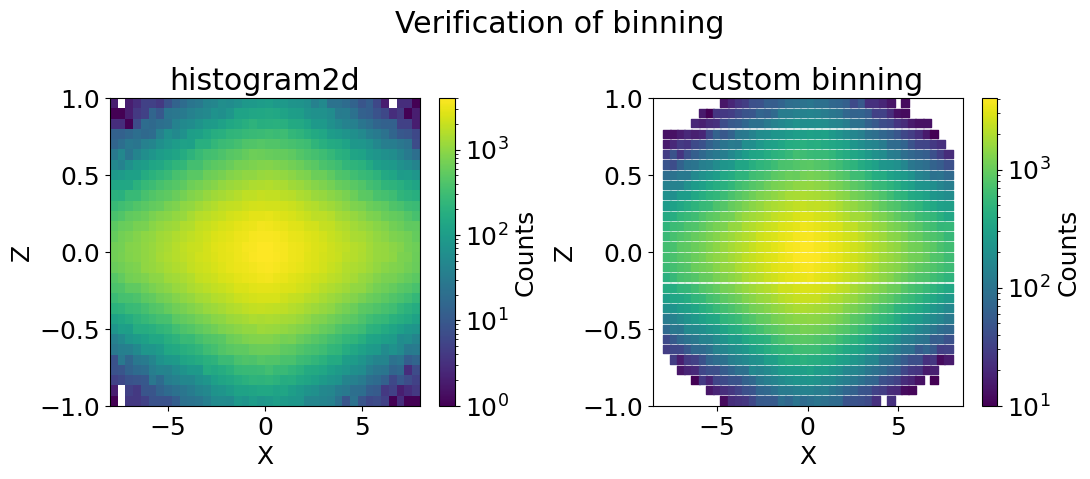

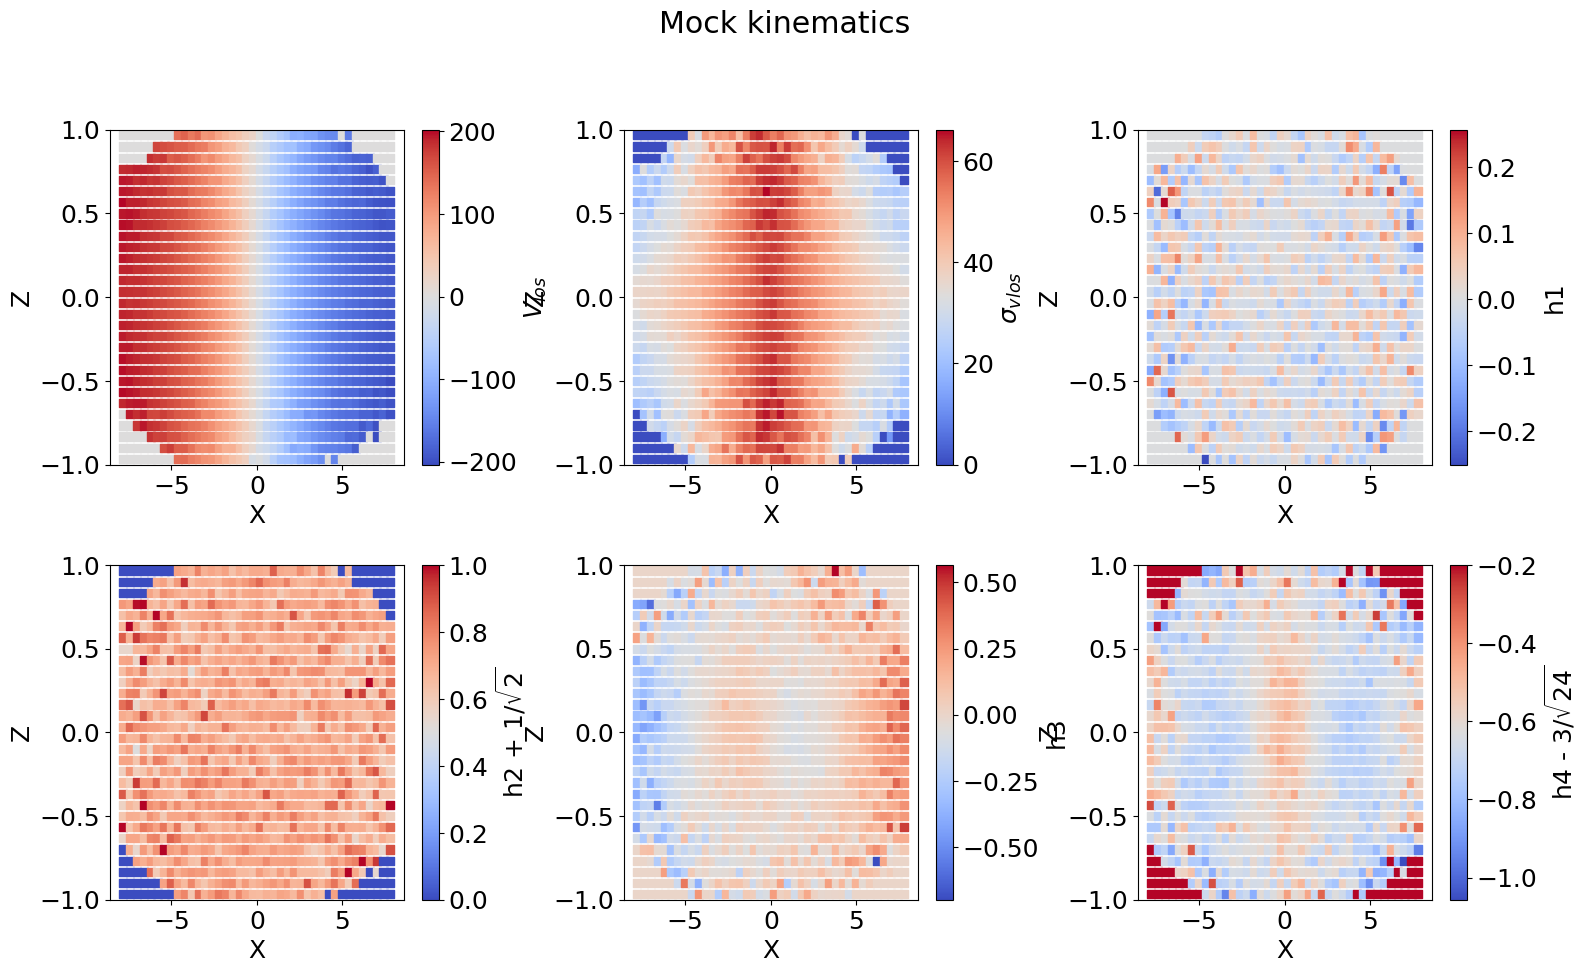

In [50]:
fig, ax = plt.subplots(1,2,figsize=(12,4), gridspec_kw={'width_ratios': [1, 1], 'wspace':0.4})

fig.suptitle('Verification of binning', y=1.1)
H, xedge, yedge = np.histogram2d(x, z, bins=[X_edge, Y_edge])
im = ax[0].imshow(H.T, origin='lower', extent=[X_edge[0], X_edge[-1], Y_edge[0], Y_edge[-1]], aspect='auto', norm = 'log')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Z')
ax[0].set_title('histogram2d')
fig.colorbar(im, ax=ax[0], label='Counts')

im = ax[1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['N_count'], cmap='viridis', s=35, marker = 's', norm = 'log')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Z')
ax[1].set_title('custom binning')
ax[1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1], label='Counts')

fig, ax = plt.subplots(2,3,figsize=(18,10), gridspec_kw={'wspace':0.4, 'hspace':0.3})
im = ax[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_mean'], s=35, marker = 's', cmap='coolwarm')
ax[0,0].set_xlabel('X')
ax[0,0].set_ylabel('Z')
ax[0,0].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,0], label='$V_{los}$')

im = ax[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_sigma'], s=35, marker = 's', cmap='coolwarm')
ax[0,1].set_xlabel('X')
ax[0,1].set_ylabel('Z')
ax[0,1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,1], label='$\sigma_{vlos}$')

im = ax[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h1'], s=35, marker = 's', cmap='coolwarm')
ax[0,2].set_xlabel('X')
ax[0,2].set_ylabel('Z')
ax[0,2].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,2], label='h1')

im = ax[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h2'] + 1/np.sqrt(2), s=35, marker = 's', cmap='coolwarm', vmax = 1)
ax[1,0].set_xlabel('X')
ax[1,0].set_ylabel('Z')
ax[1,0].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,0], label='h2 + 1/$\sqrt{2}$')

im = ax[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h3'], s=35, marker = 's', cmap='coolwarm')
ax[1,1].set_xlabel('X')
ax[1,1].set_ylabel('Z')
ax[1,1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,1], label='h3')

im = ax[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h4'] - 3/np.sqrt(24), s=35, marker = 's', cmap='coolwarm', vmax = -0.2)
ax[1,2].set_xlabel('X')
ax[1,2].set_ylabel('Z')
ax[1,2].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,2], label='h4 - 3/$\sqrt{24}$')

fig.suptitle('Mock kinematics', y=1.0)

print('|h1-4| max:', jnp.max(jnp.fabs(df_XY['h1'].to_numpy())), 
jnp.max(jnp.fabs(df_XY['h2'].to_numpy())), 
jnp.max(jnp.fabs(df_XY['h3'].to_numpy())), 
jnp.max(jnp.fabs(df_XY['h4'].to_numpy())))

## new logL and pipeline below

In [62]:
@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


@jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    r_h1 = ( (A_h1 @ x) / density_2DXY - y_h1 ) / sig_A1
    r_h2 = ( (A_h2 @ x) / density_2DXY - y_h2 ) / sig_A2
    r_h3 = ( (A_h3 @ x) / density_2DXY - y_h3 ) / sig_A3
    r_h4 = ( (A_h4 @ x) / density_2DXY - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi)
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY)
    val3 = 0.5 * jnp.dot(r_h1, r_h1)
    val4 = 0.5 * jnp.dot(r_h2, r_h2)
    val5 = 0.5 * jnp.dot(r_h3, r_h3)
    val6 = 0.5 * jnp.dot(r_h4, r_h4)

    return val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x)#
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat


@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    A_h1 = jnp.where(jnp.fabs(A_h1)>2, 0.0, A_h1)
    A_h2 = jnp.where(jnp.fabs(A_h2)>2, -1/np.sqrt(2), A_h2)
    A_h3 = jnp.where(jnp.fabs(A_h3)>2, 0.0, A_h3)
    A_h4 = jnp.where(jnp.fabs(A_h4)>2, 3/np.sqrt(24), A_h4)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    frac_err_min = 0.1
    sig_A1 = jnp.where(frac_err_min * y_h1 > dict_data['h1_data_err'], frac_err_min * y_h1, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(frac_err_min * y_h2 > dict_data['h2_data_err'], frac_err_min * y_h2, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(frac_err_min * y_h3 > dict_data['h3_data_err'], frac_err_min * y_h3, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(frac_err_min * y_h4 > dict_data['h4_data_err'], frac_err_min * y_h4, dict_data['h4_data_err']) + EPSILON

    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1e-3, maxiter=500)

    weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / density_2DXY
    h2_model = (A_h2 @ weights) / density_2DXY
    h3_model = (A_h3 @ weights) / density_2DXY
    h4_model = (A_h4 @ weights) / density_2DXY

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)
    

    return V_model, sigma_model, h3_model, h4_model, weights


@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    V_model, sigma_model, h3_model, h4_model, weights = model(params_halo_pot, params_disk_rho, dict_data)

    # jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    # jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    # jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    # jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    # jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    # jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    # jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    # jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())

    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)

    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h3_data, h3_data_err = dict_data['h3_data'], dict_data['h3_data_err']
    h4_data, h4_data_err = dict_data['h4_data'], dict_data['h4_data_err']

    frac_err_min = 0.1
    V_data_err = jnp.where(frac_err_min * V_data > V_data_err, frac_err_min * V_data, V_data)
    sigma_data_err = jnp.where(frac_err_min * sigma_data > sigma_data_err, frac_err_min * sigma_data, sigma_data)
    h3_data_err = jnp.where(frac_err_min * h3_data > h3_data_err, frac_err_min * h3_data, h3_data)
    h4_data_err = jnp.where(frac_err_min * h4_data > h4_data_err, frac_err_min * h4_data, h4_data)

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((V_model - V_data)**2) / (V_data_err + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((sigma_model - sigma_data)**2) / (sigma_data_err + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((h3_model - h3_data)**2) / (h3_data_err + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((h4_model - h4_data)**2) / (h4_data_err + 1e-3) )

    return log_likelihood

In [ ]:
aaaaa

In [63]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-1199950600.0


In [64]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

  5%|▌         | 1/20 [02:21<44:49, 141.57s/it]

-1238666800.0


 10%|█         | 2/20 [04:36<41:19, 137.77s/it]

-1238611100.0


 15%|█▌        | 3/20 [06:59<39:41, 140.11s/it]

...

-1261720600.0


 95%|█████████▌| 19/20 [45:53<02:26, 146.33s/it]

-1263861100.0


100%|██████████| 20/20 [48:24<00:00, 145.24s/it]

-1265379500.0
